### Imports

In [ ]:
import numpy as np
import pandas as pd
import csv
import json
import argparse
from sklearn.metrics import accuracy_score
import graphviz
from sklearn.tree import export_graphviz
from imblearn.over_sampling import SMOTE
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.metrics import classification_report
pd.options.mode.chained_assignment = None
from sklearn.metrics import confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Definitions

In [ ]:
class_numbers = ['messaging_apps', 'multimedia_apps']
features_t = ['Min differential Packet Length', 'Max differential Packet Length', 'IAT min', 'IAT max', 'Packet Length Total', 'Min Packet Length', 'Max Packet Length', 'Flow Duration']

In [ ]:
# Function to get scores of the model under test
def get_scores(classes, depth, n_tree, feats, max_leaf, X_train, y_train, X_test, y_test):

    model = RandomForestClassifier(
        max_depth=depth,
        n_estimators=n_tree,
        max_leaf_nodes=max_leaf,
        n_jobs=4,
        random_state=42,
        bootstrap=False,
        class_weight='balanced'
    )

    model.fit(X_train[feats], y_train)
    y_pred = model.predict(X_test[feats])

    # ✅ Explicitly define label indices to match class_numbers
    labels = list(range(len(class_numbers)))  # e.g., [0, 1]
    print(labels)
    class_report = classification_report(
        y_test,
        y_pred,
        labels=labels,
        target_names=class_numbers,
        output_dict=True,
        zero_division=0
    )

    macro_score = class_report['macro avg']['f1-score']
    weighted_score = class_report['weighted avg']['f1-score']

    return model, class_report, macro_score, weighted_score, y_pred

# Function to save final model for later analysis
def save_model(model, filename):
    pickle.dump(model, open(filename, 'wb'))

# Function to separate data into features and labels
def extract_x_y(Dataset, classes, features):
    Dataset = Dataset[Dataset["Label"].isin(class_numbers)]
    X = Dataset[features]
    y = Dataset['Label'].replace(class_numbers, range(len(class_numbers)))
    return X, y

# Function to Fit model based on optimal values of depth and number of estimators and use it
# to compute feature importance for all the features.
def get_feature_importance(depth, n_tree, max_leaf, X_train, y_train):
    rf_opt = RandomForestClassifier(max_depth = depth, n_estimators = n_tree,
                                    max_leaf_nodes=max_leaf, random_state=42, bootstrap=False, class_weight='balanced')
    rf_opt.fit(X_train, y_train)
    feature_importance = pd.DataFrame(rf_opt.feature_importances_)
    feature_importance.index = X_train.columns
    feature_importance = feature_importance.sort_values(by=list(feature_importance.columns),axis=0,ascending=False)

    return feature_importance

# Function to Fit model based on optimal values of depth and number of estimators and feature importance
# to find the fewest possible features to exceed the previously attained score with all selected features
def get_fewest_features(importance):
    sorted_feature_names = importance.index
    features = []
    for f in range(1,len(sorted_feature_names)+1):
        features.append(sorted_feature_names[0:f])
    return features

# Function to analyze different combinations of model hyperparameters
def analyze_models(class_numbers, model_type, depths, n_trees, X_train, y_train, X_test, y_test, max_leaf, filename_out):
    # Create a list to hold the results
    results = []

    if model_type == 'RF':
        # FOR EACH (depth, n_tree, feat)
        for depth in depths:
            for n_tree in n_trees:
                # get feature orders to use
                importance = get_feature_importance(depth, n_tree, max_leaf, X_train, y_train)
                print(importance)
                plt.figure(figsize=(10, 6))
                plt.barh(importance.index, importance[0])
                plt.gca().invert_yaxis()
                plt.title("Feature Importance in Random Forest")
                plt.xlabel("Importance Score")
                plt.ylabel("Feature")
                plt.tight_layout()
                plt.show()
                m_feats = get_fewest_features(importance)
                for feats in m_feats:
                    # Get the scores with the given (depth, n_tree, feat)
                    model, c_report, macro_f1, weight_f1, y_pred = get_scores(
                        class_numbers, depth, n_tree, feats, max_leaf, X_train, y_train, X_test, y_test
                    )

                    # Append results as a dictionary
                    results.append({
                        "depth": depth,
                        "n_tree": n_tree,
                        "max_leaf": max_leaf,
                        "n_feat": len(feats),
                        "macro": macro_f1,
                        "weighted": weight_f1,
                        "features": list(feats),  # Convert features to a list
                        "c_report": c_report  # Add the classification report
                    })

    # Write the results to a .json file
    with open(filename_out, mode="w") as file:
        json.dump(results, file, indent=4)  # Pretty-print JSON with an indentation of 4 spaces

    print("Analysis Complete. Check output file.")
    return []

def find_best_parameters(json_file, metric="weighted"):
    # Load the JSON file
    with open(json_file, 'r') as file:
        data = json.load(file)

    # Check if data is empty
    if not data:
        print("The JSON file is empty!")
        return None

    # Find the best configuration based on the specified metric
    best_config = max(data, key=lambda x: x[metric])

    # Print summary including depth
    print("Best Configuration:")
    print(f"Depth: {best_config['depth']}")
    print(f"N_tree: {best_config['n_tree']}")
    print(f"Max_leaf: {best_config['max_leaf']}")
    print(f"Number of Features: {best_config['n_feat']}")
    print(f"{metric.capitalize()} F1 Score: {best_config[metric]}")
    print(f"Features: {best_config['features']}")
    print(f"Classification Report: {best_config['c_report']}")

    return best_config

def evaluate_model_overfitting(model, X_train, y_train, X_test, y_test):
    # Evaluate training performance
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_report = classification_report(y_train, y_train_pred, output_dict=True)

    # Evaluate test performance
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_report = classification_report(y_test, y_test_pred, output_dict=True)

    # Analyze performance difference
    performance_diff = train_accuracy - test_accuracy
    if performance_diff > 0.1:  # Large gap between train and test
        evaluation = "The model is likely overfitting. Try regularization or simplifying the model."
    elif train_accuracy < 0.6 and test_accuracy < 0.6:  # Both low accuracies
        evaluation = "The model is likely underfitting. Try increasing complexity or adding more features."
    else:
        evaluation = "The model has a good balance between training and testing performance."

    # Print and return results
    results = {
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Train Report": train_report,
        "Test Report": test_report,
        "Evaluation": evaluation
    }

    print(f"Train Accuracy: {train_accuracy}")
    print(f"Test Accuracy: {test_accuracy}")
    print(f"Performance Difference: {performance_diff}")
    print(f"Evaluation: {evaluation}")

    return results

# --- Plot Confusion Matrix as a Heatmap ---

def plot_confusion_matrix(conf_matrix, labels, save_path="confusion_matrix.png"):
    labels = ['facebook', 'instagram', 'linkedin', 'spotify', 'tiktok', 'twitter', 'wikipedia', 'youtube']

    # Scale accuracy values to percentages
    conf_matrix = np.round(conf_matrix * 100, 2)

    plt.figure(figsize=(12, 10))
    plt.rcParams["font.family"] = "Quattrocento Sans"

    heatmap = sns.heatmap(
        conf_matrix,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={'size': 22}
    )

    plt.xlabel("Predicted (Classes)", fontsize=22)
    plt.ylabel("Actual (Classes)", fontsize=22)

    # Set tick label font sizes and align x labels to center under ticks
    plt.xticks(rotation=30, ha='center', fontsize=22)
    plt.yticks(rotation=0, fontsize=22)

    # Colorbar customization
    colorbar = heatmap.collections[0].colorbar
    colorbar.set_ticks([0, 20, 40, 60, 80, 100])
    colorbar.set_ticklabels(["0", "20", "40", "60", "80", "100"])
    colorbar.ax.tick_params(labelsize=22)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_metrics_bar_chart(accuracy, precision, recall, weighted_f1, macro_f1, save_path="metrics_plot.png"):
    metrics = ["Accuracy", "Precision", "Recall", "Weighted F1", "Macro F1"]
    scores = [accuracy, precision, recall, weighted_f1, macro_f1]

    font_size = 44  # Set the desired font size for all elements

    plt.figure(figsize=(24, 12))  # Increase width for better spacing
    bars = plt.bar(metrics, scores, color=["navy", "darkblue", "royalblue", "steelblue", "skyblue"])
    plt.ylim(60, 100)

    # Adding text annotations with specified font properties
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, score + 1, f"{score:.1f}",
                 ha="center", fontsize=font_size, fontfamily="Quattrocento Sans")

    # Apply font size to axis labels, title, and ticks
    plt.ylabel("Score [%]", fontsize=font_size, fontfamily="Quattrocento Sans")
    plt.xticks(fontsize=font_size, fontfamily="Quattrocento Sans")  # Rotate for spacing
    plt.yticks(fontsize=font_size, fontfamily="Quattrocento Sans")
    plt.title("Model Performance Metrics", fontsize=font_size, fontfamily="Quattrocento Sans")

    # Save the image
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Define ANSI escape code for #8F493F (approximate as a terminal color)
COLOR_CODE = "\033[38;2;143;73;63m"  # RGB escape sequence for the desired color
RESET_CODE = "\033[0m"  # Reset color

# --- Function to Compute TP, TN, FP, FN for Each Class ---
def compute_per_class_metrics(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    num_classes = conf_matrix.shape[0]  # Number of classes
    TP = np.diag(conf_matrix)  # True Positives
    FP = conf_matrix.sum(axis=0) - TP  # False Positives
    FN = conf_matrix.sum(axis=1) - TP  # False Negatives
    TN = conf_matrix.sum() - (FP + FN + TP)  # True Negatives

    return TP, TN, FP, FN

# --- Function to Display Per-Class Metrics with Color ---
def display_per_class_metrics(y_true, y_pred):
    labels = sorted(np.unique(y_true))  # Extract unique class labels
    TP, TN, FP, FN = compute_per_class_metrics(y_true, y_pred)

    print(f"\n{COLOR_CODE}=== Per-Class Confusion Metrics ==={RESET_CODE}")
    for i, label in enumerate(labels):
        print(f"{COLOR_CODE}Class {label}:{RESET_CODE}")
        print(f"{COLOR_CODE}  - TP: {TP[i]}, TN: {TN[i]}, FP: {FP[i]}, FN: {FN[i]}{RESET_CODE}")
        print(f"{COLOR_CODE}" + "-" * 40 + f"{RESET_CODE}")

# --- Function to Plot the Confusion Matrix for Each Class ---
def plot_per_class_metrics(y_true, y_pred):
    labels = sorted(np.unique(y_true))  # Extract unique class labels
    TP, TN, FP, FN = compute_per_class_metrics(y_true, y_pred)

    # Create subplots for each class
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # Adjust layout for 6 classes

    for idx, ax in enumerate(axes.flat):
        if idx >= len(labels):
            ax.axis("off")  # Hide extra subplots if classes are less than 6
            continue

        # Confusion Matrix for the class
        matrix = np.array([[f"TP\n{TP[idx]}", f"FP\n{FP[idx]}"],
                           [f"FN\n{FN[idx]}", f"TN\n{TN[idx]}"]])
        colors = np.array([[0, 1], [1, 0]])  # Blue for TP & TN, White for FP & FN

        # Heatmap with custom font properties
        sns.heatmap(colors, annot=matrix, fmt='', cmap="Blues", cbar=False,
                    xticklabels=["+", "-"], yticklabels=["+", "-"],
                    annot_kws={'size': 45, 'fontfamily': 'Quattrocento Sans'}, ax=ax)

        ax.set_xlabel("Actual Class", fontsize=40, fontname="Quattrocento Sans")
        ax.set_ylabel("Predicted Class", fontsize=40, fontname="Quattrocento Sans")
        ax.set_title(f"Class {labels[idx]}", fontsize=40, fontname="Quattrocento Sans")

    plt.tight_layout()
    plt.savefig("per_class_confusion_matrices.png", dpi=300, bbox_inches="tight")  # Save figure
    plt.show()


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


### Load input data

In [ ]:
train_data  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/train_two_class_latest_1.csv")

train_data = train_data[train_data['Label'].isin(class_numbers)]
train_data.describe()

,Min Packet Length,Max Packet Length,Packet Length Total,Min differential Packet Length,Max differential Packet Length,IAT min,IAT max,IAT Range,Flow Duration,Packet Length Range,First4Sum,Last4Sum
count,4751.000000,4751.000000,4751.000000,4751.000000,4751.00000,4.751000e+03,4.751000e+03,4.751000e+03,4.751000e+03,4751.000000,4751.000000,4751.000000
mean,92.600295,932.038939,3281.507262,18.580720,822.15281,2.956411e+04,1.681593e+06,1.652029e+06,4.970139e+08,839.438644,1568.286045,1713.221217
std,148.497823,524.831859,2668.044740,86.109918,510.77642,8.703422e+05,2.709888e+07,2.708667e+07,6.124343e+09,518.473282,1478.730484,1586.653532
min,40.000000,40.000000,320.000000,0.000000,0.00000,0.000000e+00,2.500000e+01,0.000000e+00,1.630000e+02,0.000000,160.000000,160.000000
25%,40.000000,384.000000,1175.000000,0.000000,305.00000,4.000000e+00,9.964100e+04,8.486900e+04,3.816265e+05,316.000000,448.000000,438.000000
50%,92.000000,1312.000000,2322.000000,0.000000,1073.00000,5.500000e+01,1.000000e+05,9.990700e+04,8.970200e+07,1197.000000,941.000000,1119.000000
75%,104.000000,1381.000000,4737.000000,0.000000,1269.00000,9.970000e+02,1.880105e+05,1.843040e+05,2.918215e+08,1277.000000,2155.000000,2551.000000
max,1480.000000,1500.000000,11840.000000,1237.000000,1460.00000,3.000575e+07,1.124713e+09,1.124713e+09,2.100000e+11,1460.000000,6000.000000,6000.000000


In [ ]:
test_data  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/test_two_class_latest_1.csv")

test_data = test_data[test_data['Label'].isin(class_numbers)]
test_data.describe()

,Min Packet Length,Max Packet Length,Packet Length Total,Min differential Packet Length,Max differential Packet Length,IAT min,IAT max,IAT Range,Flow Duration,Packet Length Range,First4Sum,Last4Sum
count,53021.000000,53021.000000,53021.000000,53021.000000,53021.000000,53021.000000,5.302100e+04,5.302100e+04,5.302100e+04,53021.000000,53021.000000,53021.000000
mean,68.460252,874.066540,2886.769374,47.726882,762.630807,9393.228230,1.195924e+08,1.195830e+08,1.309104e+08,805.606288,1529.461874,1357.307501
std,177.782157,537.003024,2665.200831,145.785935,510.036457,24426.391867,1.478178e+09,1.478179e+09,1.521836e+09,536.646890,1596.460351,1424.409513
min,40.000000,40.000000,320.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,160.000000,160.000000
25%,40.000000,345.000000,920.000000,0.000000,290.000000,73.000000,1.466900e+05,1.450350e+05,2.100770e+05,303.000000,338.000000,371.000000
50%,40.000000,875.000000,1880.000000,0.000000,817.000000,263.000000,6.070800e+05,5.967380e+05,1.225277e+06,817.000000,923.000000,845.000000
75%,40.000000,1480.000000,4152.000000,9.000000,1241.000000,3902.000000,1.299816e+06,1.285807e+06,2.585266e+06,1440.000000,1938.000000,1794.000000
max,1480.000000,1500.000000,11840.000000,1378.000000,1460.000000,475094.000000,3.806294e+10,3.806293e+10,5.199779e+10,1460.000000,6000.000000,6000.000000


In [ ]:
# Calculate the Pearson correlation matrix
numeric_data = train_data.select_dtypes(include=['number'])

correlation_matrix = numeric_data.corr()

In [ ]:
# Calculate the Pearson correlation matrix
numeric_data = test_data.select_dtypes(include=['number'])

correlation_matrix = numeric_data.corr()

### Segregating the data

In [ ]:
# Shuffle the data
train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

### Feature engineering

In [ ]:
features_t = ['Min differential Packet Length', 'Min Packet Length', 'Max Packet Length', 'Flow Duration', 'IAT Range', 'Packet Length Range', 'First4Sum', 'Last4Sum']

In [ ]:
X_train, y_train = extract_x_y(train_data, class_numbers, features_t)

X_test,  y_test  = extract_x_y(test_data, class_numbers, features_t)

print(class_numbers)

['messaging_apps', 'multimedia_apps']


In [ ]:
# Confirm scores of selected model
model = RandomForestClassifier(criterion="gini", max_depth=15, n_estimators = 3, max_leaf_nodes=20, min_samples_split=2, min_samples_leaf=1, n_jobs=4, random_state=42, bootstrap=False)

model.fit(X_train[features_t], y_train)

# Evaluate the model
evaluate_model_overfitting(model, X_train, y_train, X_test, y_test)

y_pred = model.predict(X_test[features_t])

y_true = y_test

y_scores = model.predict_proba(X_test)

class_report = classification_report(y_test, y_pred, target_names=class_numbers, output_dict = True)

print(classification_report)

macro_score = class_report['macro avg']['f1-score']
weighted_score = class_report['weighted avg']['f1-score']

print("Macro Score: ", macro_score)
print("Weighted Score: ", weighted_score)

df = pd.DataFrame(class_report).transpose()

df


Train Accuracy: 1.0
Test Accuracy: 0.9986231870390977
Performance Difference: 0.0013768129609023072
Evaluation: The model has a good balance between training and testing performance.
<function classification_report at 0x789c9aaf4040>
Macro Score:  0.9842665441040699
Weighted Score:  0.9986438795626774


,precision,recall,f1-score,support
messaging_apps,1.000000,0.998593,0.999296,51871.000000
multimedia_apps,0.940311,1.000000,0.969237,1150.000000
accuracy,0.998623,0.998623,0.998623,0.998623
macro avg,0.970155,0.999296,0.984267,53021.000000
weighted avg,0.998705,0.998623,0.998644,53021.000000


In [ ]:
print("TRAIN value counts:\n", y_train.value_counts())
print("TEST  value counts:\n", y_test.value_counts())


TRAIN value counts:
 Label
1    2669
0    2082
Name: count, dtype: int64
TEST  value counts:
 Label
0    51871
1     1150
Name: count, dtype: int64


In [ ]:
print("Unique train labels:", sorted(y_train.unique()))
print("Unique test  labels:", sorted(y_test.unique()))

Unique train labels: [np.int64(0), np.int64(1)]
Unique test  labels: [np.int64(0), np.int64(1)]


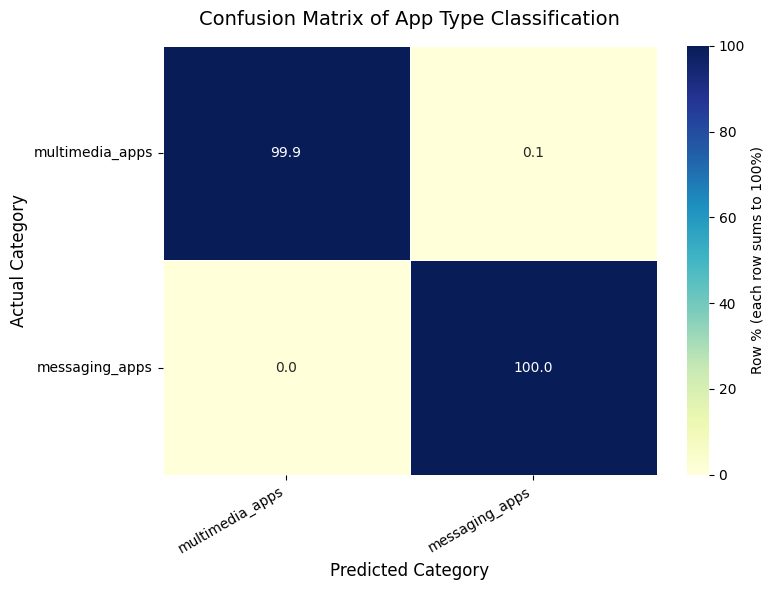

In [ ]:
# Define your 2-class labels
labels = ["multimedia_apps", "messaging_apps"]

# Compute confusion matrix (normalized per row)
conf_matrix = confusion_matrix(y_test, y_pred, labels=np.arange(len(labels)), normalize="true") * 100

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
ax = sns.heatmap(conf_matrix, annot=True, fmt=".1f", cmap="YlGnBu",
                 cbar_kws={'label': 'Row % (each row sums to 100%)'},
                 linewidths=0.5, linecolor="white")

# Labels and formatting
ax.set_xlabel("Predicted Category", fontsize=12)
ax.set_ylabel("Actual Category", fontsize=12)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticklabels(labels, rotation=0)
plt.title("Confusion Matrix of App Type Classification", fontsize=14, pad=15)

plt.tight_layout()
plt.savefig("confusion_matrix_4classes.pdf", bbox_inches="tight")
plt.show()

In [ ]:
num_cols = train_data.select_dtypes(exclude=['object']).columns
# cols = [col for col in num_cols if 'Fwd' in col or 'Bwd' in col]

<Axes: >

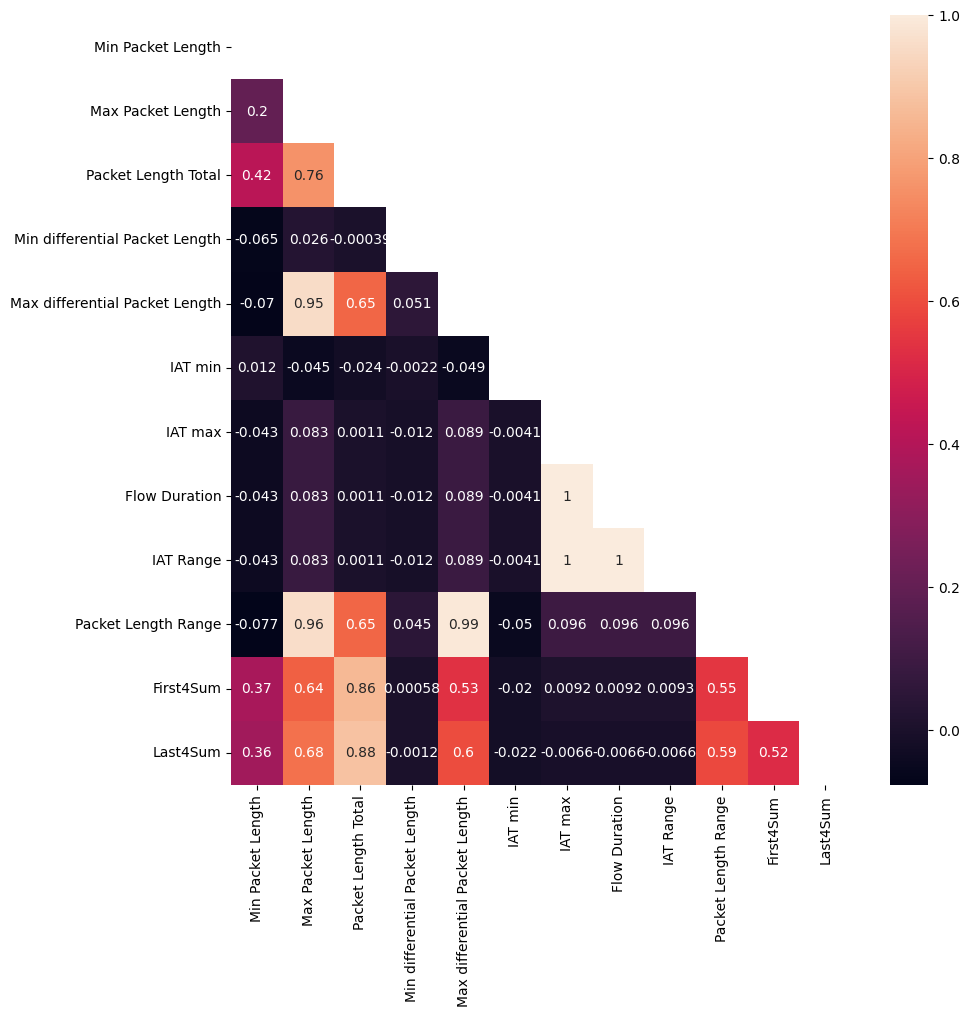

In [ ]:
corr = train_data[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool_))
plt.subplots(figsize=(10,10))
sns.heatmap(corr, annot=True, mask=mask)

### Save the model

In [ ]:
save_model(model, "categorical_classification.pkl")